In [1]:
import numpy as np
import torch
import torch.nn.functional as F
from matplotlib import pyplot as plt
from PIL import Image
import torchvision
from pathlib import Path
from torchvision import transforms
from diffusers import DDPMScheduler, UNet2DModel, DDIMPipeline
from dataset import LatentAudioDataset, decode_audio, encode_audio, load_model as load_audio_codec
from IPython.display import Audio


# Mac users may need device = 'mps' (untested)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [ ]:
EMBEDDINGS_PATH = Path("C:/Users/dzluk/stable-audio-tools/data/blackbird/embeddings")


# We'll train on 32-pixel square images, but you can try larger sizes too
image_size = 64
# You can lower your batch size if you're running out of GPU memory
batch_size = 4
# training takes about 2 mins per epoch
epochs = 10

# Define data augmentations
# preprocess = transforms.Compose(
#     [
#         transforms.Resize((image_size, image_size)),  # Resize
#         transforms.RandomHorizontalFlip(),  # Randomly flip (data augmentation)
#         transforms.ToTensor(),  # Convert to tensor (0, 1)
#         transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
#     ]
# )

# preprocess = transforms.Compose(
#     [
#         transforms.Lambda(lambda x: x[:, :, :64]),
#         # transforms.ToTensor(),  # Convert to tensor (0, 1)
#         # transforms.Normalize([0.5], [0.5]),  # Map to (-1, 1)
#     ]
# )

dataset = LatentAudioDataset(EMBEDDINGS_PATH, normalize=False, dim=64)

# Create a dataloader from the dataset to serve up the transformed images in batches
train_dataloader = torch.utils.data.DataLoader(
    dataset, batch_size=batch_size, shuffle=True
)

In [ ]:
x = next(iter(train_dataloader))[0]
x.min(), x.max()

In [3]:

noise_scheduler = DDPMScheduler(num_train_timesteps=1000)

# Create a model
model = UNet2DModel(
    sample_size=image_size,  # the target image resolution
    in_channels=1,  # the number of input channels, 3 for RGB images
    out_channels=1,  # the number of output channels
    layers_per_block=2,  # how many ResNet layers to use per UNet block
    block_out_channels=(64, 128, 128, 256),  # More channels -> more parameters
    down_block_types=(
        "DownBlock2D",  # a regular ResNet downsampling block
        "DownBlock2D",
        "AttnDownBlock2D",  # a ResNet downsampling block with spatial self-attention
        "AttnDownBlock2D",
    ),
    up_block_types=(
        "AttnUpBlock2D",
        "AttnUpBlock2D",  # a ResNet upsampling block with spatial self-attention
        "UpBlock2D",
        "UpBlock2D",  # a regular ResNet upsampling block
    ),
)
model.to(device)

UNet2DModel(
  (conv_in): Conv2d(1, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (time_proj): Timesteps()
  (time_embedding): TimestepEmbedding(
    (linear_1): Linear(in_features=64, out_features=256, bias=True)
    (act): SiLU()
    (linear_2): Linear(in_features=256, out_features=256, bias=True)
  )
  (down_blocks): ModuleList(
    (0): DownBlock2D(
      (resnets): ModuleList(
        (0-1): 2 x ResnetBlock2D(
          (norm1): GroupNorm(32, 64, eps=1e-05, affine=True)
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (time_emb_proj): Linear(in_features=256, out_features=64, bias=True)
          (norm2): GroupNorm(32, 64, eps=1e-05, affine=True)
          (dropout): Dropout(p=0.0, inplace=False)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
          (nonlinearity): SiLU()
        )
      )
      (downsamplers): ModuleList(
        (0): Downsample2D(
          (conv): Conv2d(64, 64, ker

c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\diffusers\configuration_utils.py:141: FutureWarning: Accessing config attribute `num_train_timesteps` directly via 'DDPMScheduler' object attribute is deprecated. Please access 'num_train_timesteps' over 'DDPMScheduler's config object instead, e.g. 'scheduler.config.num_train_timesteps'.
  deprecate("direct config name access", "1.0.0", deprecation_message, standard_warn=False)


Epoch:5, loss: 0.3872240878621577
Epoch:10, loss: 0.377368859050455


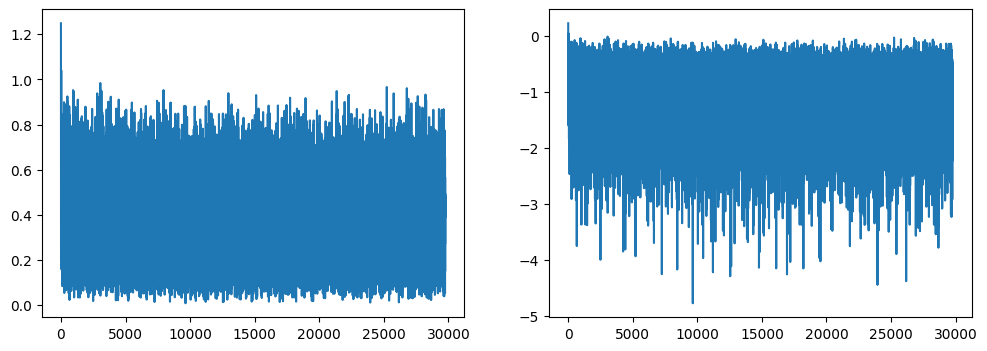

In [4]:
# Set the noise scheduler
noise_scheduler = DDPMScheduler(
    num_train_timesteps=1000, beta_schedule="squaredcos_cap_v2", clip_sample=False
)
assert noise_scheduler.config.clip_sample is False

# Training loop
optimizer = torch.optim.AdamW(model.parameters(), lr=4e-4)

losses = []

for epoch in range(epochs):
    for step, batch in enumerate(train_dataloader):
        clean_images = batch.to(device)
        # Sample noise to add to the images
        noise = torch.randn(clean_images.shape).to(clean_images.device)
        bs = clean_images.shape[0]

        # Sample a random timestep for each image
        timesteps = torch.randint(
            0, noise_scheduler.num_train_timesteps, (bs,), device=clean_images.device
        ).long()

        # Add noise to the clean images according to the noise magnitude at each timestep
        noisy_images = noise_scheduler.add_noise(clean_images, noise, timesteps)

        # Get the model prediction
        noise_pred = model(noisy_images, timesteps, return_dict=False)[0]

        # Calculate the loss
        loss = F.mse_loss(noise_pred, noise)
        loss.backward(loss)
        losses.append(loss.item())

        # Update the model parameters with the optimizer
        optimizer.step()
        optimizer.zero_grad()

    if (epoch + 1) % 5 == 0:
        loss_last_epoch = sum(losses[-len(train_dataloader) :]) / len(train_dataloader)
        print(f"Epoch:{epoch+1}, loss: {loss_last_epoch}")

fig, axs = plt.subplots(1, 2, figsize=(12, 4))
axs[0].plot(losses)
axs[1].plot(np.log(losses))
plt.show()

In [ ]:
# save trained model
trained_pipeline = DDIMPipeline(unet=model, scheduler=noise_scheduler)
trained_pipeline.scheduler.config.clip_sample = False
trained_pipeline.save_pretrained("diffusers-latent-audio-pipeline")

In [ ]:
# load from pretrained
pipe = DDIMPipeline.from_pretrained("diffusers-latent-audio-pipeline")
assert pipe.scheduler.config.clip_sample is False

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00, 72.73it/s]


DDIMScheduler {
  "_class_name": "DDIMScheduler",
  "_diffusers_version": "0.36.0",
  "beta_end": 0.02,
  "beta_schedule": "squaredcos_cap_v2",
  "beta_start": 0.0001,
  "clip_sample": false,
  "clip_sample_range": 1.0,
  "dynamic_thresholding_ratio": 0.995,
  "num_train_timesteps": 1000,
  "prediction_type": "epsilon",
  "rescale_betas_zero_snr": false,
  "sample_max_value": 1.0,
  "set_alpha_to_one": true,
  "steps_offset": 0,
  "thresholding": false,
  "timestep_spacing": "leading",
  "trained_betas": null
}

In [2]:
# load from pretrained
pipe = DDIMPipeline.from_pretrained(r"diffusers-training-runs\run_20260302_100727\pipeline")
assert pipe.scheduler.config.clip_sample is False

Loading pipeline components...: 100%|██████████| 2/2 [00:00<00:00,  6.85it/s]


In [4]:
# load SAO codec
audio_codec, audio_codec_params = load_audio_codec()

def sample(x, model, scheduler, num_sampling_steps):
    """
    Given a noise sample x, iteratively denoise it num_sampling_steps times using the model and scheduler
    x has shape (b, 1, 64, 64)
    """

    scheduler.set_timesteps(num_sampling_steps)

    for t in scheduler.timesteps:
        with torch.no_grad():
            noise_pred = model(x, t).sample

        x = scheduler.step(
            noise_pred, t, x
        ).prev_sample

    return x

Loading pretrained model stabilityai/stable-audio-open-1.0


c:\Users\dzluk\Syrinx\audio-diffusion-course\.venv\Lib\site-packages\torch\nn\utils\weight_norm.py:144: FutureWarning: `torch.nn.utils.weight_norm` is deprecated in favor of `torch.nn.utils.parametrizations.weight_norm`.
  WeightNorm.apply(module, name, dim)
Loading weights: 100%|██████████| 99/99 [00:00<00:00, 1466.67it/s, Materializing param=shared.weight]                                                      


Done loading model
Loaded pretrained model: stabilityai/stable-audio-open-1.0
Device: cuda | Half: False | Sample rate: 44100 | Sample size: 2097152


In [11]:
# sample
pipe = pipe.to(device)

noise = torch.randn((1, 1, 64, 64), device=device)
sampled = sample(noise, pipe.unet, pipe.scheduler, 100)[0]
x = sampled.cpu().numpy()
print("Mean:", x.mean(), "Std:", x.std(), "Min:", x.min(), "Max:", x.max())

audio = decode_audio(sampled, audio_codec, jupyter=True).cpu().numpy()
display(Audio(audio, rate=44100))

Mean: 0.036820795 Std: 1.3658773 Min: -4.6177506 Max: 6.127405


In [20]:
# Audio to Audio
import torchcodec

input_audio_path = Path(r"C:\Users\dzluk\stable-audio-tools\inputs\blackbird.wav")
ad = torchcodec.decoders.AudioDecoder(input_audio_path, sample_rate=44100)
audio = ad.get_all_samples().data


In [16]:
encoding = encode_audio(audio, 44100, audio_codec, audio_codec_params, device)
# decoding = decode_audio(encoding, audio_codec)
# display(Audio(decoding.cpu(), rate=44100))   

In [ ]:
# sample


# TODO: in order to make audio-to-audio work, we have to modify the noise scheduler so that it starts the noise step based on noise_mix
encoding = encode_audio(audio, 44100, audio_codec, audio_codec_params, device)

noise_mix = 1

pipe = pipe.to(device)

encoding = encoding[...,:64].unsqueeze(0) # trim last dim to 64 and add batch dim

noise = torch.randn((1, 1, 64, 64), device=device)
latent_input = encoding * (1 - noise_mix) + noise * noise_mix 

sampled = sample(latent_input, pipe.unet, pipe.scheduler, 50)[0]
x = sampled.cpu().numpy()
print("Mean:", x.mean(), "Std:", x.std(), "Min:", x.min(), "Max:", x.max())

decoded_audio = decode_audio(sampled, audio_codec).cpu().numpy()
display(Audio(decoded_audio, rate=44100))

Mean: -0.030142074 Std: 0.95156187 Min: -3.3221347 Max: 3.6049705
